# Arrival model tuning charts (sketch)

Three **Preview-tier lottery** charts for the PR #78 arrival settings pane — each pairs 1:1 with a studio slider. Discrete outcome bars show probability mass; orange overlays give **Λ** (cumulative exposure in reference-days) for each outcome. Closed-form math only: gamma duration pmf, Poisson break counts, thermal-mode φ_set — **no** Prior rebake, **no** cargo/PyO3.

**Defaults** from `data/abdella/arrival_model.json` (ρ=0 clean chain unless noted, `abdella_all` duration corridor, thermal mode mix).


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gamma as gamma_dist
from scipy.stats import poisson

%matplotlib inline

REPO = Path.cwd().resolve()
if not (REPO / "src" / "blueberries_voi").is_dir():
    REPO = REPO.parent
assert (REPO / "data" / "abdella" / "arrival_model.json").is_file(), REPO

ARTIFACT_PATH = REPO / "data" / "abdella" / "arrival_model.json"
ARTIFACT = json.loads(ARTIFACT_PATH.read_text())

Q10 = float(ARTIFACT["q10"])
T_REF = float(ARTIFACT["T_ref"])
RHO_DEF = float(ARTIFACT["rho"])
TAU_BAR_DEF = float(ARTIFACT["tau_bar"])
T_BREAK_DEF = float(ARTIFACT["T_break"])

D_MED = 5.5
D_BAR = 5.5
PREVIEW_D_DEFAULT = 5
LAMBDA_FLOOR = 1e-6
THERMAL_MODE_NAMES = ("cool", "nominal", "warm")


def phi(t_c, q10: float = Q10, t_ref: float = T_REF):
    """Q10 store-temperature factor (matches `store_temp_factor`)."""
    t_arr = np.asarray(t_c, dtype=float)
    return np.power(q10, (t_arr - t_ref) / 10.0)


def phi_set_from_legs(artifact: dict, bias_c: float = 0.0) -> float:
    """Duration-weighted leg φ with optional uniform ΔT bias on setpoints."""
    return sum(
        leg["weight"] * phi(leg["setpoint_c"] + bias_c, artifact["q10"], artifact["T_ref"])
        for leg in artifact["legs"]
    )


def phi_set_for_thermal_mode(
    artifact: dict,
    mode_name: str,
    bias_c: float = 0.0,
) -> float:
    offset_c = float(artifact["thermal_modes"][mode_name]["offset_c"])
    return phi_set_from_legs(artifact, bias_c=bias_c + offset_c)


def phi_break(t_break: float, artifact: dict | None = None) -> float:
    art = ARTIFACT if artifact is None else artifact
    return phi(t_break, art["q10"], art["T_ref"])


def break_exposure_rate(phi_set: float, phi_brk: float) -> float:
    return max(phi_brk - phi_set, 0.0)


def lambda_clean(d: float, phi_set: float) -> float:
    return max(d * phi_set, LAMBDA_FLOOR)


def lambda_with_breaks(
    d: float,
    n_breaks: int,
    tau_bar: float,
    phi_set: float,
    phi_brk: float,
) -> float:
    ber = break_exposure_rate(phi_set, phi_brk)
    return max(d * phi_set + n_breaks * tau_bar * ber, LAMBDA_FLOOR)


def duration_pmf_integer_days(
    artifact: dict,
    days: range | None = None,
    corridor_key: str = "abdella_all",
) -> dict[int, float]:
    """Discretized pmf P(d ≈ k) for k ∈ {2,…,7} from d_min + Gamma(shape, scale)."""
    if days is None:
        days = range(2, 8)
    corridor = artifact["corridors"][corridor_key]
    d_min = float(corridor["d_min"])
    shape = float(corridor["delay_shape"])
    scale = float(corridor["delay_scale"])
    probs: dict[int, float] = {}
    for k in days:
        lo = max(k - 0.5 - d_min, 0.0)
        hi = k + 0.5 - d_min
        probs[k] = float(gamma_dist.cdf(hi, shape, scale=scale) - gamma_dist.cdf(lo, shape, scale=scale))
    total = sum(probs.values())
    return {k: v / total for k, v in probs.items()}


PHI_SET_DEF = phi_set_from_legs(ARTIFACT)
PHI_BREAK_DEF = phi_break(T_BREAK_DEF)


## Chart 1 — `preview_transit_days` → Duration lottery

Pack date pins calendar transit duration **d** for the Preview tier: the studio slider `preview_transit_days` (2–7 d) is the merchandising face of “how long did this lot sit in transit?”. Under a **clean chain** (ρ=0, nominal thermal bias) cumulative exposure is Λ = **d·φ_set**, so each integer day is a lottery outcome weighted by the `abdella_all` delayed-gamma corridor.

Bars show the discretized pmf P(d ≈ k) for k ∈ {2,…,7} from **d_min + Gamma(a, b)**; the orange line (right axis) is **Λ_k = k·φ_set** — exposure if the trip lasted exactly k days. Default slider highlight at **d = 5**; no break or Prior rebake.

| Variable | Role |
|----------|------|
| `preview_transit_days` | Studio slider (2–7 d); sketch highlights **5 d** |
| `d` | Integer transit days (lottery outcome) |
| `φ_set` | Duration-weighted Q10 factor at leg setpoints (ρ=0, ΔT=0) |
| `Λ_k` | `k · φ_set` (clean chain exposure) |
| `abdella_all` | Corridor: d_min + delayed gamma |


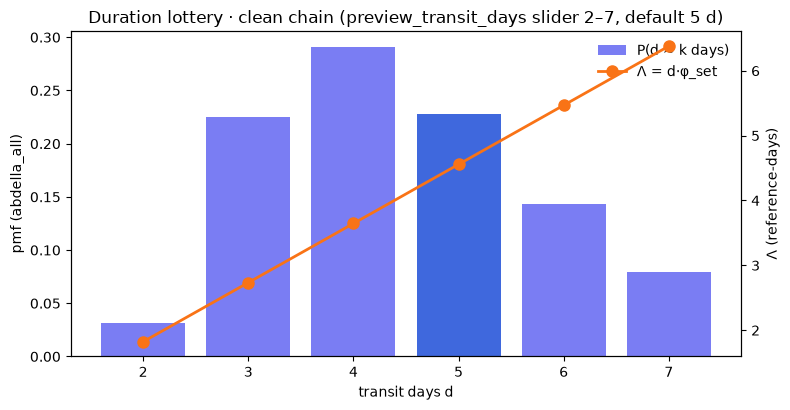

In [2]:
phi_set = PHI_SET_DEF
days = np.arange(2, 8)
pmf_by_day = duration_pmf_integer_days(ARTIFACT)
pmf = np.array([pmf_by_day[int(k)] for k in days])
lambdas = np.array([lambda_clean(float(k), phi_set) for k in days])
default_idx = int(PREVIEW_D_DEFAULT - 2)
bar_colors = ["#6366f1"] * len(days)
bar_colors[default_idx] = "#1d4ed8"

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(days, pmf, color=bar_colors, alpha=0.85, label="P(d ≈ k days)")
ax.set_xlabel("transit days d")
ax.set_ylabel("pmf (abdella_all)")
ax.set_xticks(days)
ax2 = ax.twinx()
ax2.plot(days, lambdas, "o-", color="#f97316", lw=2, ms=8, label="Λ = d·φ_set")
ax2.set_ylabel("Λ (reference-days)")
ax.set_title(
    f"Duration lottery · clean chain (preview_transit_days slider 2–7, default {PREVIEW_D_DEFAULT} d)"
)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=False)
plt.tight_layout()
plt.show()


## Chart 2 — `break_rho` → Break lottery

Cold-chain breaks are a **compound-Poisson** process: at hazard **ρ** breaks per transit-day on a trip of length **d̄**, the count N ~ Poisson(ρ·d̄). Each break adds exposure τ̄·(φ_break − φ_set) on top of the clean baseline **d̄·φ_set**. The `break_rho` slider (0–0.15 / day) is the merchandising face of ρ — turn it up and more mass moves from N = 0 to N ≥ 1 without simulating individual pulses.

Bars show the Poisson pmf for N = 0…4 at fixed **d̄ = 5.5 d**; the orange line (right axis) is the **ΔΛ** each count implies via `lambda_with_breaks`. Sketch uses **ρ = 0.08** (artifact default).

| Variable | Role |
|----------|------|
| `break_rho` | Studio slider (0–0.15 / day); sketch uses **0.08** |
| `d̄` | Fixed typical transit (5.5 d) |
| `N` | Break count ~ Poisson(ρ·d̄) |
| `ΔΛ_N` | `N · τ̄ · (φ_break − φ_set)` add-on over clean baseline |
| `τ̄`, `φ_break` | Artifact defaults |


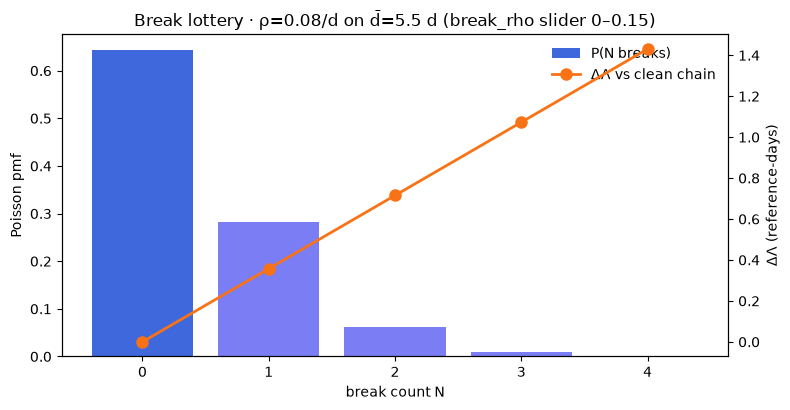

In [3]:
rho = RHO_DEF
tau_bar = TAU_BAR_DEF
phi_set = PHI_SET_DEF
phi_brk = PHI_BREAK_DEF
mu = rho * D_BAR
ns = np.arange(0, 5)
pmf = poisson.pmf(ns, mu)
delta_lam = [
    lambda_with_breaks(D_BAR, int(n), tau_bar, phi_set, phi_brk) - lambda_clean(D_BAR, phi_set)
    for n in ns
]

fig, ax = plt.subplots(figsize=(8, 4.2))
bar_colors = ["#6366f1"] * len(ns)
bar_colors[0] = "#1d4ed8"
ax.bar(ns, pmf, color=bar_colors, alpha=0.85, label="P(N breaks)")
ax.set_xlabel("break count N")
ax.set_ylabel("Poisson pmf")
ax.set_xticks(ns)
ax2 = ax.twinx()
ax2.plot(ns, delta_lam, "o-", color="#f97316", lw=2, ms=8, label="ΔΛ vs clean chain")
ax2.set_ylabel("ΔΛ (reference-days)")
ax.set_title(f"Break lottery · ρ={rho:.2f}/d on d̄={D_BAR} d (break_rho slider 0–0.15)")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=False)
plt.tight_layout()
plt.show()


## Chart 3 — `transit_temp_bias_c` → Trip thermal mode lottery

Trip-wide temperature uncertainty is a **three-outcome lottery** from the artifact `thermal_modes`: cool / nominal / warm with probabilities **p** and setpoint offsets **offset_c**. Duration-weighted φ_set(mode) = φ(leg setpoints + offset + bias) captures how each mode ages product in transit. The `transit_temp_bias_c` slider (−2…+8 °C) uniformly shifts every leg setpoint — it slides the whole ladder, not individual bars.

Bars show mode probabilities at **ΔT = 0** (slider centre); the orange line (right axis) is **Λ_mode = d̄·φ_set(mode)** at fixed **d̄ = 5.5 d**, **ρ = 0**. Nominal mode highlighted; turning `transit_temp_bias_c` re-evaluates all three φ_set values in lockstep.

| Variable | Role |
|----------|------|
| `transit_temp_bias_c` | Studio slider (−2…+8 °C); sketch at **0** |
| `thermal_modes` | cool / nominal / warm (p, offset_c) from artifact |
| `φ_set(mode)` | Duration-weighted Q10 factor per mode |
| `Λ_mode` | `d̄ · φ_set(mode)` at ρ=0 |
| `d̄` | Fixed 5.5 d (duration lottery separate) |


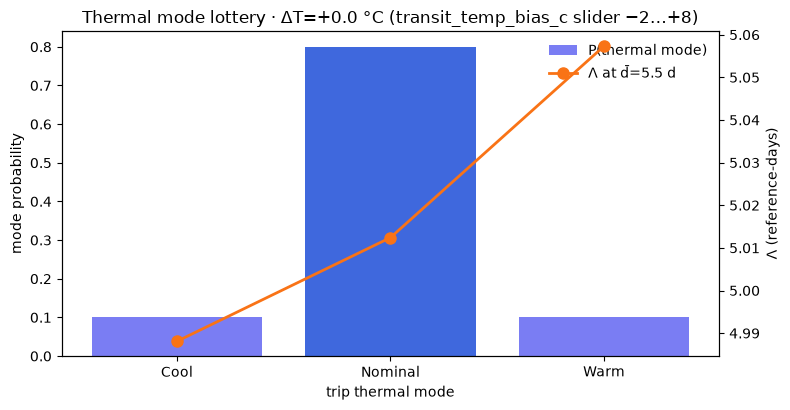

In [4]:
bias_c = 0.0
modes = THERMAL_MODE_NAMES
mode_labels = [m.capitalize() for m in modes]
probs = np.array([float(ARTIFACT["thermal_modes"][m]["p"]) for m in modes])
phi_sets = np.array([phi_set_for_thermal_mode(ARTIFACT, m, bias_c=bias_c) for m in modes])
lambdas = np.array([lambda_clean(D_MED, ps) for ps in phi_sets])
x = np.arange(len(modes))
bar_colors = ["#6366f1"] * len(modes)
bar_colors[1] = "#1d4ed8"  # nominal

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(x, probs, color=bar_colors, alpha=0.85, label="P(thermal mode)")
ax.set_xlabel("trip thermal mode")
ax.set_ylabel("mode probability")
ax.set_xticks(x, mode_labels)
ax2 = ax.twinx()
ax2.plot(x, lambdas, "o-", color="#f97316", lw=2, ms=8, label=f"Λ at d̄={D_MED} d")
ax2.set_ylabel("Λ (reference-days)")
ax.set_title(
    f"Thermal mode lottery · ΔT={bias_c:+.1f} °C (transit_temp_bias_c slider −2…+8)"
)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=False)
plt.tight_layout()
plt.show()
